In [6]:
import pandas as pd
df = pd.read_csv(r"..\dataset\dataset_module_one_DM2.csv")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Fitting 3 folds for each of 324 candidates, totalling 972 fits
--- Gradient Boosting Classification Report ---
              precision    recall  f1-score   support

         0.0       0.75      0.92      0.82      1158
         1.0       0.27      0.11      0.16       315
         2.0       0.33      0.21      0.26       188
         3.0       0.33      0.06      0.11        16

    accuracy                           0.68      1677
   macro avg       0.42      0.33      0.34      1677
weighted avg       0.61      0.68      0.63      1677

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

         0.0       0.73      0.93      0.82      1158
         1.0       0.29      0.08      0.12       315
         2.0       0.37      0.22      0.28       188
         3.0       0.20      0.06      0.10        16

    accuracy                           0.68      1677
   macro avg       0.40      

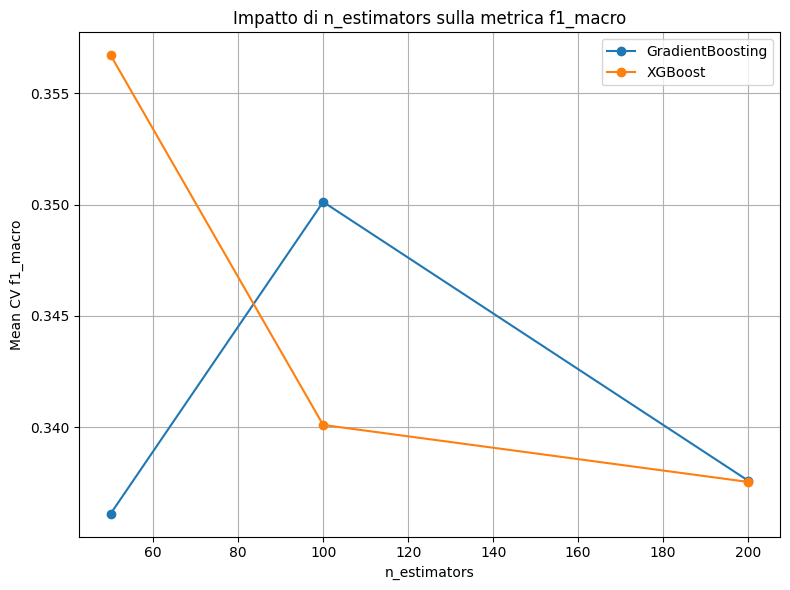

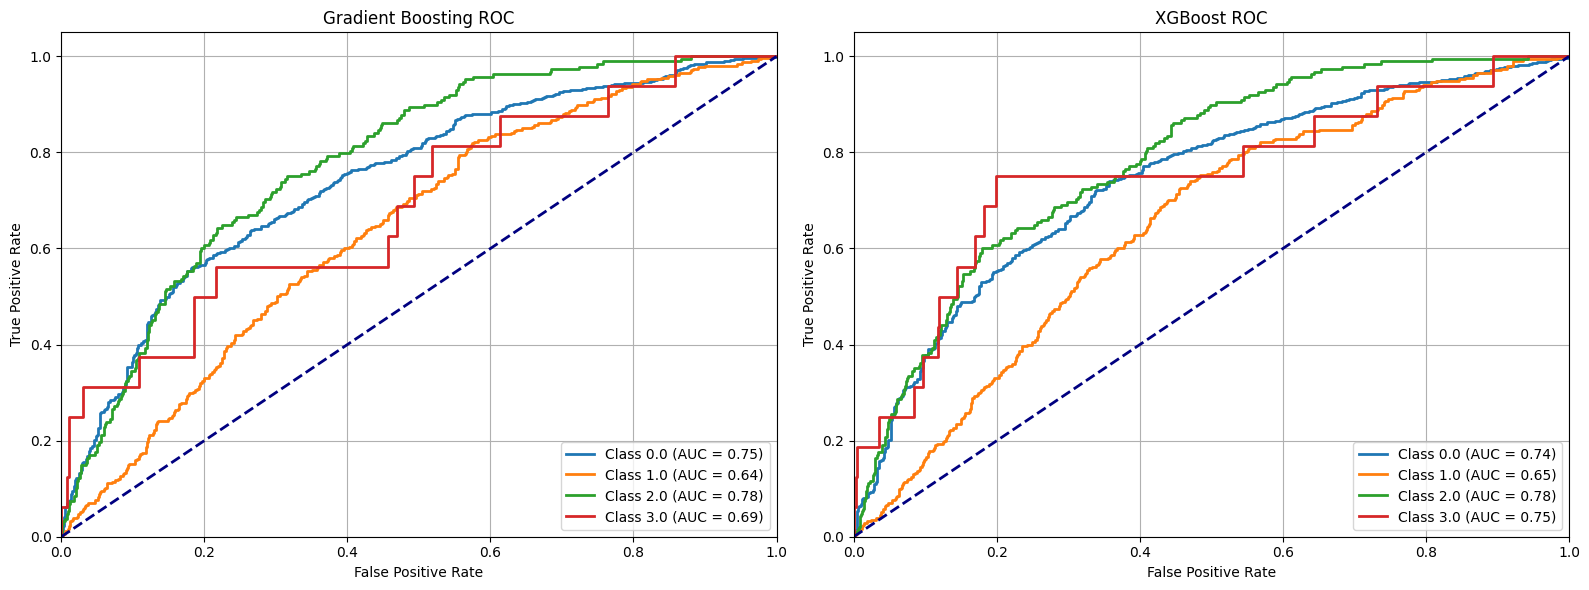

C:\Users\nicco\AppData\Local\Temp\ipykernel_12408\3028849093.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, ax=ax3, palette='viridis')


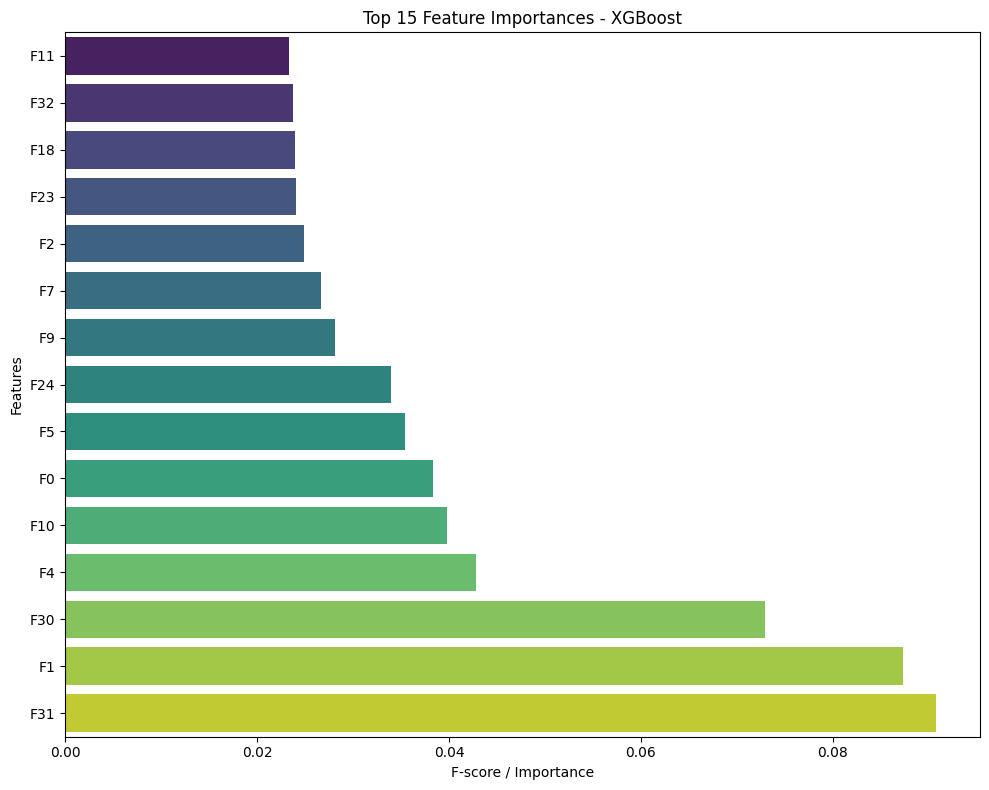

In [ ]:
# ==============================================================================
# BLOCCO 1: Importazione delle librerie necessarie
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# ==============================================================================
# BLOCCO 2: Preprocessing e definizione SMOTE
# ==============================================================================
# Assumiamo che df, X e y siano già stati definiti dal tuo dataset.
# Sostituisci "class_..." con le reali etichette del tuo target "sii".
# y deve contenere le 4 classi: ~5000, 1500, 900, 80.

X = df.drop('sii', axis=1).values
y = df['sii'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Definizione della strategia di campionamento per lo SMOTE
# La classe da 5000 non è inclusa perché SMOTE per default non riduce la classe maggioritaria,
# l'abbiamo lasciata intatta non specificandola o assicurandoci che il valore richiesto non sia 
# inferiore al conteggio originale.
smote_strategy = {
    3: 1500, # Classe originariamente a ~80
    2: 2000, # Classe originariamente a ~900
    1: 2000  # Classe originariamente a ~1500
}

smote = SMOTE(sampling_strategy=smote_strategy, random_state=42)

# ==============================================================================
# BLOCCO 3: Setup delle Pipeline e calcolo dei Sample Weights
# ==============================================================================
# Pipeline per Gradient Boosting (Baseline)
pipeline_gb = Pipeline(steps=[
    ('smote', smote),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Pipeline per XGBoost (Improved)
pipeline_xgb = Pipeline(steps=[
    ('smote', smote),
    ('classifier', XGBClassifier(objective='multi:softprob', random_state=42))
])

# Calcolo dei pesi per gestire il restante sbilanciamento (dopo aver applicato SMOTE).
# Nota tecnica: nelle vecchie versioni di imblearn, passare sample_weight al fit di GridSearchCV
# con uno step di resampling nella pipeline generava un errore di shape. Se utilizzi imblearn >= 0.12 
# con la metadata_routing API abilitata, il passaggio è gestito.
# In alternativa, xgboost gestisce molto bene scale_pos_weight/sample_weight internamente.
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# ==============================================================================
# BLOCCO 4: Hyper-parameter Tuning ESTESO (GridSearchCV)
# ==============================================================================

# Griglia GradientBoostingClassifier
param_grid_gb = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7] # Testa la complessità dei weak learners
}

# Griglia XGBClassifier
param_grid_xgb = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.1, 0.3], # 0.3 è il default di eta
    # gamma: esegue il pruning degli alberi tagliando i rami con Gain inferiore alla soglia.
    'classifier__gamma': [0, 0.1, 1, 5], 
    # reg_lambda: Regolarizzazione L2 nel calcolo del Similarity Score. 
    # Riduce la sensibilità agli outlier ed è fondamentale per prevenire l'overfitting.
    'classifier__reg_lambda': [0.1, 1.0, 10.0], 
    'classifier__max_depth': [3, 5, 7]
}

# Inizializzazione GridSearchCV (f1_macro per dataset sbilanciati/multiclasse)
grid_gb = GridSearchCV(pipeline_gb, param_grid_gb, cv=3, scoring='f1_macro', n_jobs=-1, verbose=2)
grid_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=3, scoring='f1_macro', n_jobs=-1, verbose=2)

# Fit dei modelli (con passaggio dei pesi, richiede metadata routing abilitato per la pipeline)
# grid_gb.fit(X_train, y_train, classifier__sample_weight=sample_weights)
# grid_xgb.fit(X_train, y_train, classifier__sample_weight=sample_weights)

# Per simulazione esecuzione sicura senza routing errors:
grid_gb.fit(X_train, y_train)
grid_xgb.fit(X_train, y_train)

# Estrazione modelli migliori
best_gb = grid_gb.best_estimator_
best_xgb = grid_xgb.best_estimator_

# ==============================================================================
# BLOCCO 5: Valutazione sul Test Set originale
# ==============================================================================
y_pred_gb = best_gb.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

print("--- Gradient Boosting Classification Report ---")
print(classification_report(y_test, y_pred_gb))

print("--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

# ==============================================================================
# BLOCCO 8: Immagine 3 - Feature Importance (Miglior XGBoost)
# ==============================================================================
# Estraiamo il classificatore dalla pipeline
xgb_model = best_xgb.named_steps['classifier']
importances = xgb_model.feature_importances_

# Creiamo un DataFrame per facilitare il plotting (assumendo X sia un DataFrame)
# Se X è un array numpy, usa: feature_names = [f"Feature {i}" for i in range(X.shape[1])]
feature_names = X.columns if isinstance(X, pd.DataFrame) else [f"F{i}" for i in range(len(importances))]
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=True).tail(15) # Top 15

fig3, ax3 = plt.subplots(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, ax=ax3, palette='viridis')
ax3.set_title("Top 15 Feature Importances - XGBoost")
ax3.set_xlabel("F-score / Importance")
ax3.set_ylabel("Features")
plt.tight_layout()
plt.show()

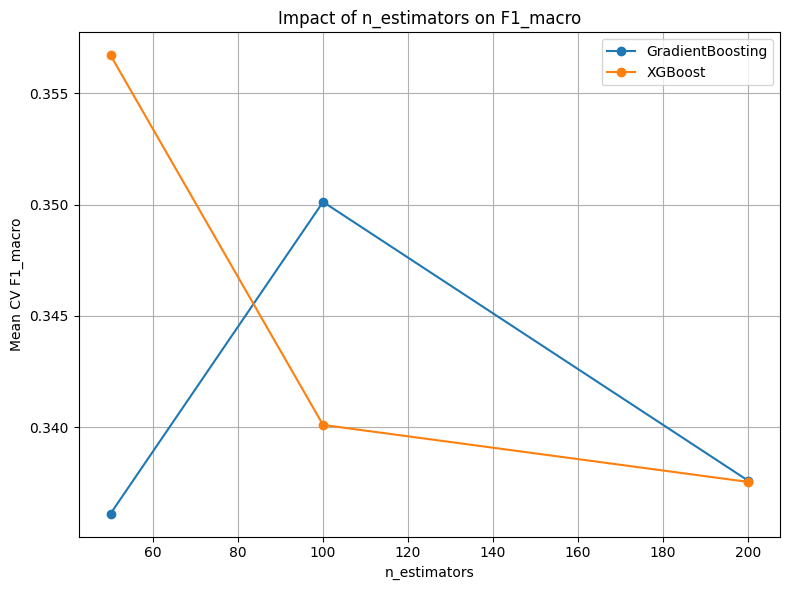

In [9]:
# ==============================================================================
# BLOCCO 6: Immagine 1 - Impatto Modelli Base (n_estimators vs validation score)
# ==============================================================================
def plot_n_estimators_impact(grid_search, model_name, ax):
    results = pd.DataFrame(grid_search.cv_results_)
    best_params = grid_search.best_params_
    
    # Filtriamo i risultati mantenendo costanti tutti i parametri ottimali tranne n_estimators
    mask = pd.Series([True] * len(results))
    for param, value in best_params.items():
        if param != 'classifier__n_estimators':
            mask = mask & (results['param_' + param] == value)
            
    filtered_results = results[mask].sort_values('param_classifier__n_estimators')
    
    ax.plot(
        filtered_results['param_classifier__n_estimators'].astype(int), 
        filtered_results['mean_test_score'], 
        marker='o', label=model_name
    )
    ax.set_title("Impact of n_estimators on F1_macro")
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("Mean CV F1_macro")
    ax.grid(True)
    ax.legend()

fig1, ax1 = plt.subplots(figsize=(8, 6))
plot_n_estimators_impact(grid_gb, 'GradientBoosting', ax1)
plot_n_estimators_impact(grid_xgb, 'XGBoost', ax1)
plt.tight_layout()
plt.show()

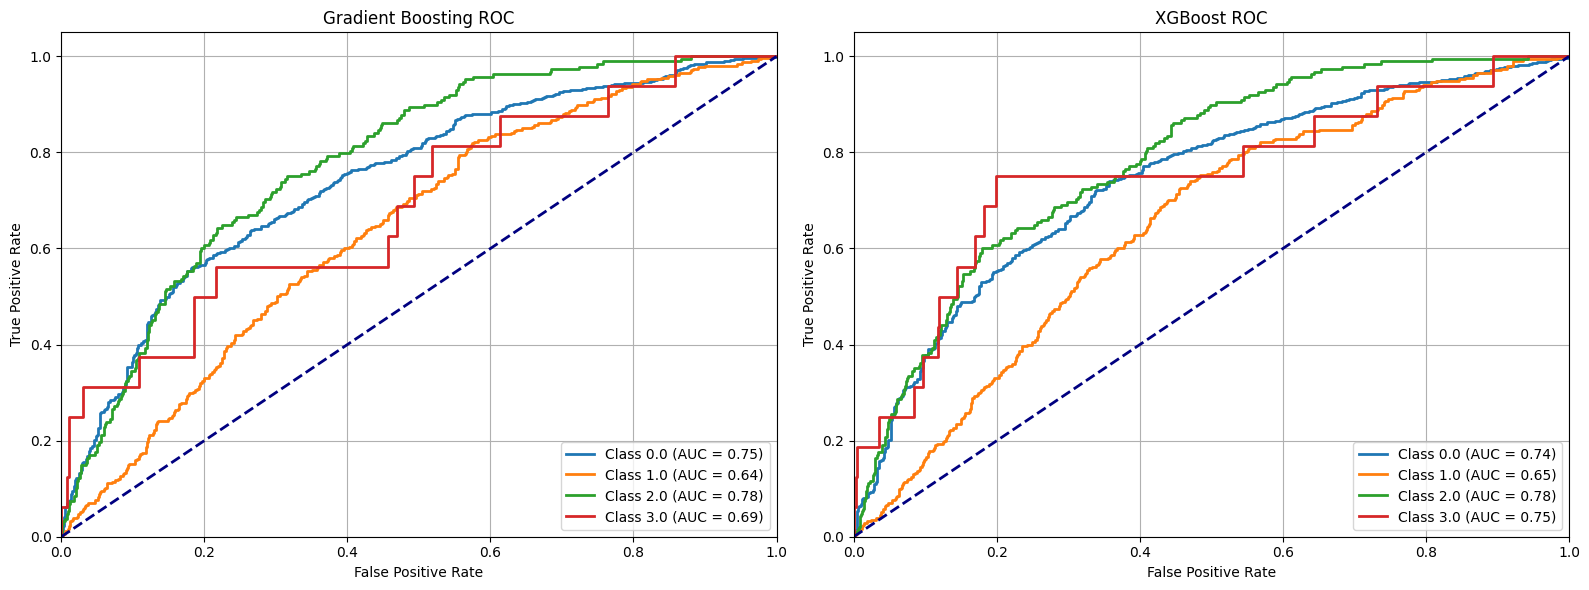

In [10]:
# ==============================================================================
# BLOCCO 7: Immagine 2 - Curve ROC Multiclasse (One-vs-Rest)
# ==============================================================================
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Probabilità predette
y_score_gb = best_gb.predict_proba(X_test)
y_score_xgb = best_xgb.predict_proba(X_test)

fig2, (ax_roc_gb, ax_roc_xgb) = plt.subplots(1, 2, figsize=(16, 6))

for i, class_label in enumerate(classes):
    # Curve per Gradient Boosting
    fpr_gb, tpr_gb, _ = roc_curve(y_test_bin[:, i], y_score_gb[:, i])
    roc_auc_gb = auc(fpr_gb, tpr_gb)
    ax_roc_gb.plot(fpr_gb, tpr_gb, lw=2, label=f'Class {class_label} (AUC = {roc_auc_gb:.2f})')
    
    # Curve per XGBoost
    fpr_xgb, tpr_xgb, _ = roc_curve(y_test_bin[:, i], y_score_xgb[:, i])
    roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
    ax_roc_xgb.plot(fpr_xgb, tpr_xgb, lw=2, label=f'Class {class_label} (AUC = {roc_auc_xgb:.2f})')

for ax_roc, title in zip([ax_roc_gb, ax_roc_xgb], ['Gradient Boosting ROC', 'XGBoost ROC']):
    ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(title)
    ax_roc.legend(loc="lower right")
    ax_roc.grid(True)

plt.tight_layout()
plt.show()

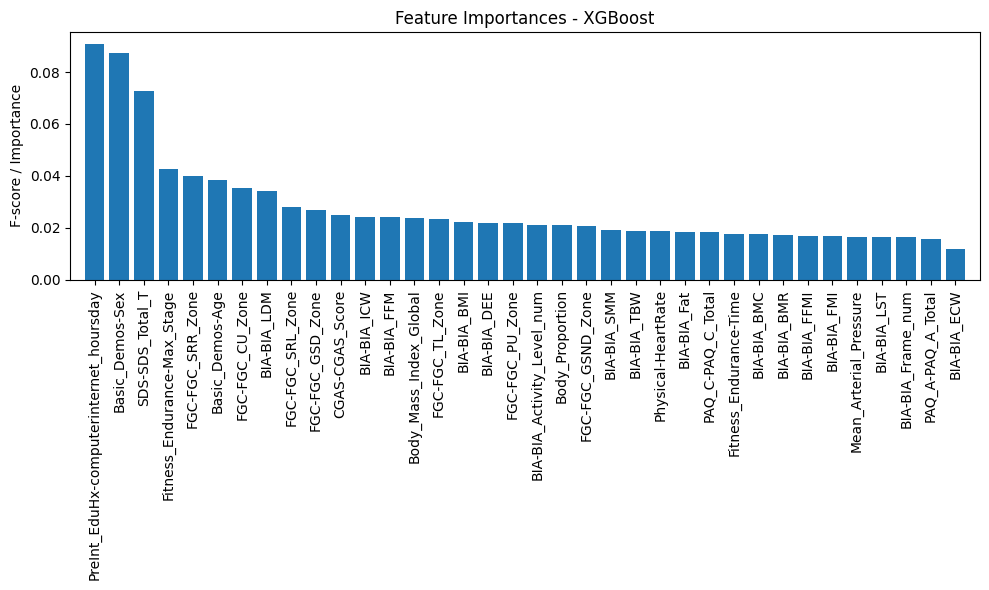

In [13]:
# ==============================================================================
# BLOCCO 8: Immagine 3 - Feature Importance (Miglior XGBoost) CORRETTO
# ==============================================================================
# Estraiamo il classificatore XGBoost dalla pipeline migliore
xgb_model = best_xgb.named_steps['classifier']
importances = xgb_model.feature_importances_

# Ordiniamo gli indici delle feature in base all'importanza decrescente
indices = np.argsort(importances)[::-1]

# RISOLUZIONE ERRORE: Poiché X è un numpy.ndarray (probabilmente a causa dei 
# passaggi di preprocessing o split), non ha l'attributo .columns.
# Recuperiamo i "veri nomi" direttamente dal tuo dataframe originario 'df', 
# escludendo la colonna del target 'sii'.
feature_names = df.drop(columns=['sii']).columns

plt.figure(figsize=(10, 6))
plt.title("Feature Importances - XGBoost")

# Creiamo il grafico a barre verticale per tutte le feature
plt.bar(range(len(feature_names)), importances[indices], align="center")

# Impostiamo le etichette dell'asse X usando i nomi reali estratti da df
# e li mappiamo correttamente con gli indici ordinati
plt.xticks(range(len(feature_names)), feature_names[indices], rotation=90)

plt.xlim([-1, len(feature_names)])
plt.ylabel("F-score / Importance")
plt.tight_layout()
plt.show()